# Exercise 1: RAPID AMOC Data Exploration

This notebook follows the Lecture 1 exercise: explore RAPID component transport data using `amocatlas` and Python.

Goals:

- Load RAPID component transport data from `moc_transports.nc`.
- Plot the main transport time series: MOC, UMO, Florida Current, and Ekman.
- Visually inspect variability and compare components.
- Calculate basic statistics: mean, variance, standard deviation, range, and sample interval.
- Make histograms and simple resampled/subsampled views.

## 1. Imports and Project Paths

The project folder contains the `data/` directory. Because this project path contains non-ASCII characters on Windows, the helper below copies the NetCDF file to a temporary ASCII-only path before `amocatlas` reads it.

In [9]:
from pathlib import Path
import shutil
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from amocatlas import read

# Make plots readable in the notebook.
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Work whether the notebook is run from the project root or from notebooks/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

DATA_FILE = DATA_DIR / "moc_transports.nc"
DATA_FILE

WindowsPath('D:/codex/作业/amoc-analysis/data/moc_transports.nc')

## 2. Load RAPID Component Data

The file `moc_transports.nc` is the RAPID layer transport file identified in the AMOCatlas metadata. It contains the component transports used in class, including UMO, MOC, Florida Current, and Ekman.

In [10]:
def load_rapid_transport_dataset(data_file: Path) -> xr.Dataset:
    """Load RAPID transport data with amocatlas, robustly on Windows paths."""
    if not data_file.exists():
        raise FileNotFoundError(f"Could not find {data_file}")

    with tempfile.TemporaryDirectory(ignore_cleanup_errors=True) as tmpdir:
        tmpdir = Path(tmpdir)
        tmp_file = tmpdir / data_file.name
        shutil.copy2(data_file, tmp_file)

        ds = read.rapid(
            source=tmpdir,
            file_list=data_file.name,
            raw=False,  # standardize variable names, e.g. t_umo10 -> TRANS_UMO
        )
        ds.load()
        ds.close()

    return ds


ds = load_rapid_transport_dataset(DATA_FILE)
ds

Loading 1 RAPID 26°N dataset(s):
  0. moc_transports.nc: RAPID layer transport time series



<xarray.Dataset> Size: 1MB
Dimensions:           (TIME: 13779)
Coordinates:
  * TIME              (TIME) datetime64[ns] 110kB 2004-04-02 ... 2023-02-11
Data variables:
    TRANS_0_800       (TIME) float64 110kB nan nan nan nan ... nan nan nan nan
    TRANS_800_1100    (TIME) float64 110kB nan nan nan nan ... nan nan nan nan
    TRANS_1100_3000   (TIME) float64 110kB nan nan nan nan ... nan nan nan nan
    TRANS_3000_5000   (TIME) float64 110kB nan nan nan nan ... nan nan nan nan
    TRANS_below_5000  (TIME) float64 110kB nan nan nan nan ... nan nan nan nan
    TRANS_FC          (TIME) float64 110kB nan nan nan nan ... nan nan nan nan
    TRANS_EKMAN       (TIME) float64 110kB nan nan nan nan ... nan nan nan nan
    TRANS_UMO         (TIME) float64 110kB nan nan nan nan ... nan nan nan nan
    MOC               (TIME) float64 110kB nan nan nan nan ... nan nan nan nan
Attributes: (12/39)
    title:                                 RAPID MOC timeseries
    summary:                               RAPID 26N transport estimates dataset
    description:                           RAPID 26N transport estimates dataset
    program:                               RAPID
    project:                               RAPID-AMOC 26掳N array
    license:                               UK Open Government Licence v3.0 ht...
    ...                                    ...
    processing_datasource:                 rapid26n
    variable_mapping:                      {'time': 'TIME', 't_therm10': 'TRA...
    original_variable_metadata:            {'t_therm10': {'long_name': 'Trans...
    applied_variable_mapping:              {'time': 'TIME', 't_therm10': 'TRA...
    version:                               2024.1a
    files:                                 {'moc_transports.nc': {'featureTyp...

## 3. Variables in the Dataset

The standardized names from `amocatlas` make the main transport components easy to compare.

In [11]:
component_vars = {
    "MOC": "Meridional overturning circulation strength",
    "TRANS_UMO": "Upper mid-ocean transport",
    "TRANS_FC": "Florida Current transport",
    "TRANS_EKMAN": "Ekman transport",
}

var_table = pd.DataFrame(
    {
        "variable": list(component_vars.keys()),
        "description": list(component_vars.values()),
        "units": [ds[var].attrs.get("units", "") for var in component_vars],
        "long_name": [ds[var].attrs.get("long_name", "") for var in component_vars],
    }
)
var_table

,variable,description,units,long_name
0,MOC,Meridional overturning circulation strength,Sverdrup,MOC_z
1,TRANS_UMO,Upper mid-ocean transport,Sverdrup,Upper mid-ocean
2,TRANS_FC,Florida Current transport,Sverdrup,Florida Current
3,TRANS_EKMAN,Ekman transport,Sverdrup,Ekman


## 4. Time Coverage and Sampling Interval

The exercise asks for the sampling interval and range of time. RAPID transport data are usually provided at a regular sub-daily interval, but checking this explicitly is good practice.

In [12]:
time = pd.to_datetime(ds["TIME"].values)
time_series = pd.Series(time).dropna().sort_values().reset_index(drop=True)
time_diffs = time_series.diff().dropna()

coverage = pd.DataFrame(
    {
        "time_start": [time_series.iloc[0]],
        "time_end": [time_series.iloc[-1]],
        "number_of_samples": [len(time_series)],
        "most_common_sampling_interval": [time_diffs.mode().iloc[0]],
        "minimum_sampling_interval": [time_diffs.min()],
        "maximum_sampling_interval": [time_diffs.max()],
    }
)
coverage

,time_start,time_end,number_of_samples,most_common_sampling_interval,minimum_sampling_interval,maximum_sampling_interval
0,2004-04-02,2023-02-11,13779,0 days 12:00:00,0 days 12:00:00,0 days 12:00:00


## 5. Plot the Main Transport Time Series

This plot compares the main RAPID component transports. Use it for the visual evaluation part of the exercise: look for seasonal variability, strong events, outliers, and long-term changes.

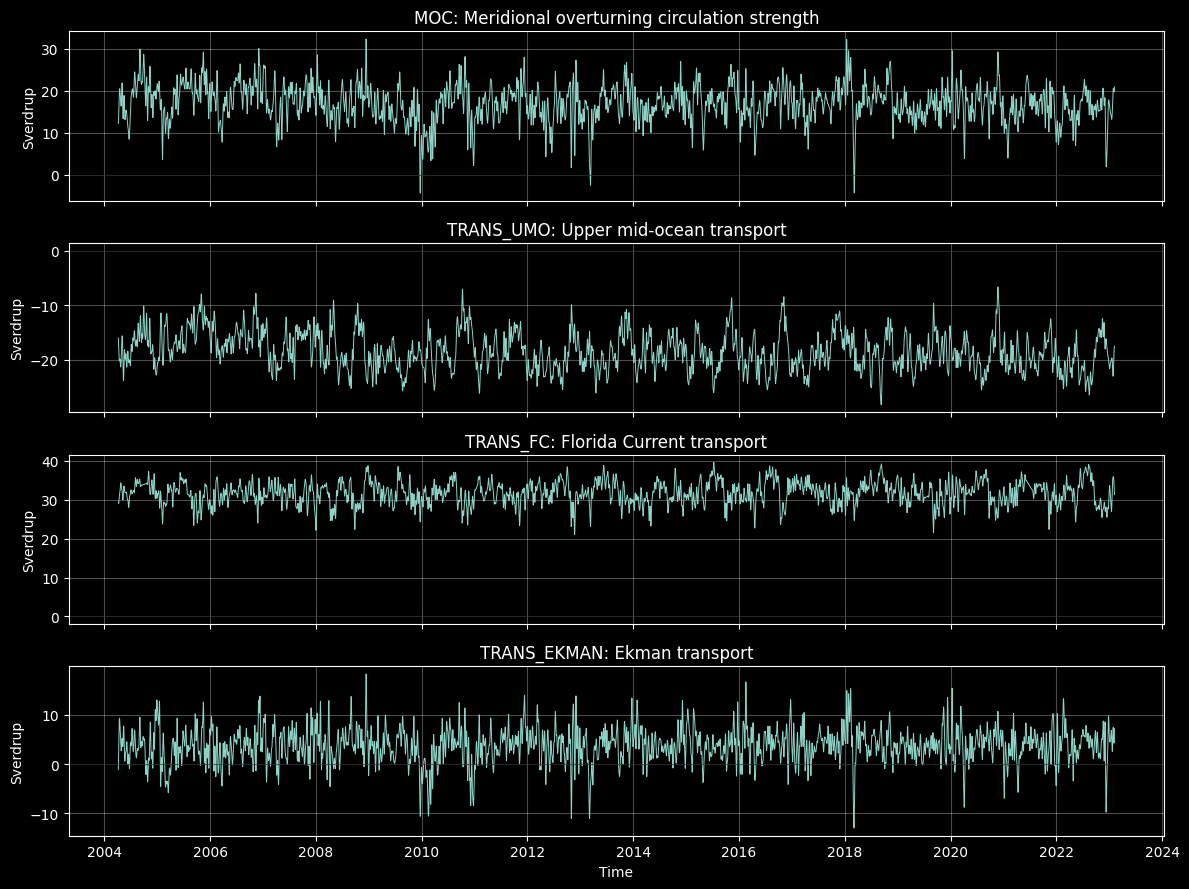

In [13]:
fig, axes = plt.subplots(len(component_vars), 1, figsize=(12, 9), sharex=True)

for ax, (var, label) in zip(axes, component_vars.items()):
    ax.plot(ds["TIME"], ds[var], linewidth=0.7)
    units = ds[var].attrs.get("units", "Sv")
    ax.set_ylabel(units)
    ax.set_title(f"{var}: {label}")
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)

axes[-1].set_xlabel("Time")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "exercise1_transport_timeseries.png", dpi=150)
plt.show()

## 6. Basic Statistics

The table below reports the mean, variance, standard deviation, minimum, maximum, and value range for each selected component.

In [15]:
stats_rows = []
for var, label in component_vars.items():
    values = ds[var].to_series().dropna()
    stats_rows.append(
        {
            "variable": var,
            "description": label,
            "count": values.count(),
            "mean": values.mean(),
            "variance": values.var(),
            "standard_deviation": values.std(),
            "minimum": values.min(),
            "maximum": values.max(),
            "value_range": values.max() - values.min(),
        }
    )

stats = pd.DataFrame(stats_rows).set_index("variable")
stats.round(3)

,description,count,mean,variance,standard_deviation,minimum,maximum,value_range
variable,,,,,,,,
MOC,Meridional overturning circulation strength,13759,17.042,18.959,4.354,-4.349,32.340,36.689
TRANS_UMO,Upper mid-ocean transport,13759,-18.419,11.836,3.440,-28.241,-6.653,21.588
TRANS_FC,Florida Current transport,13759,31.764,8.385,2.896,21.005,39.651,18.645
TRANS_EKMAN,Ekman transport,13759,3.767,11.842,3.441,-13.003,18.286,31.289


## 7. Histograms

Histograms show the distribution of transport values. This helps identify skewness, outliers, and whether one component has much larger variability than another.

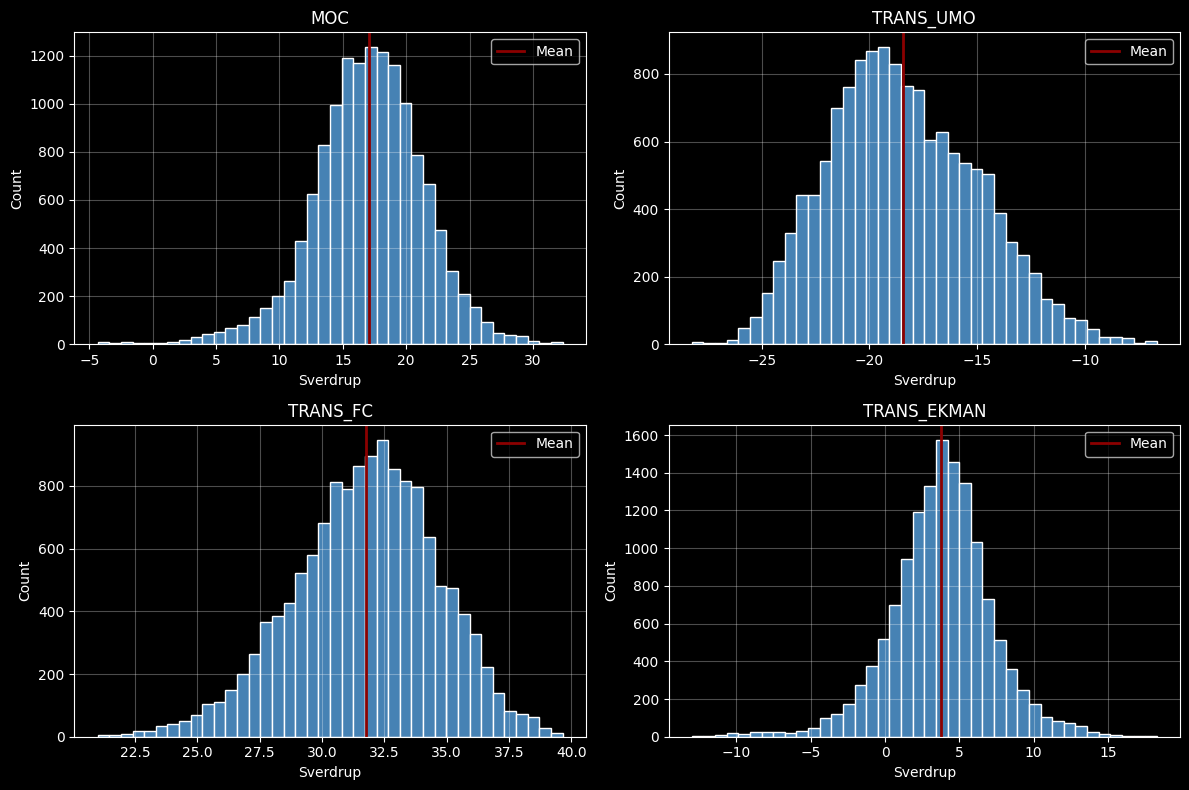

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, (var, label) in zip(axes, component_vars.items()):
    values = ds[var].to_series().dropna()
    ax.hist(values, bins=40, color="steelblue", edgecolor="white")
    ax.axvline(values.mean(), color="darkred", linewidth=2, label="Mean")
    ax.set_title(var)
    ax.set_xlabel(ds[var].attrs.get("units", "Sv"))
    ax.set_ylabel("Count")
    ax.legend()

fig.tight_layout()
fig.savefig(FIGURE_DIR / "exercise1_transport_histograms.png", dpi=150)
plt.show()

## 8. Monthly Mean and Subsampled Views

The lecture mentions regridding/subsampling onto different time grids. Here we compare raw MOC values with monthly means and a simple every-30th-sample subsample.

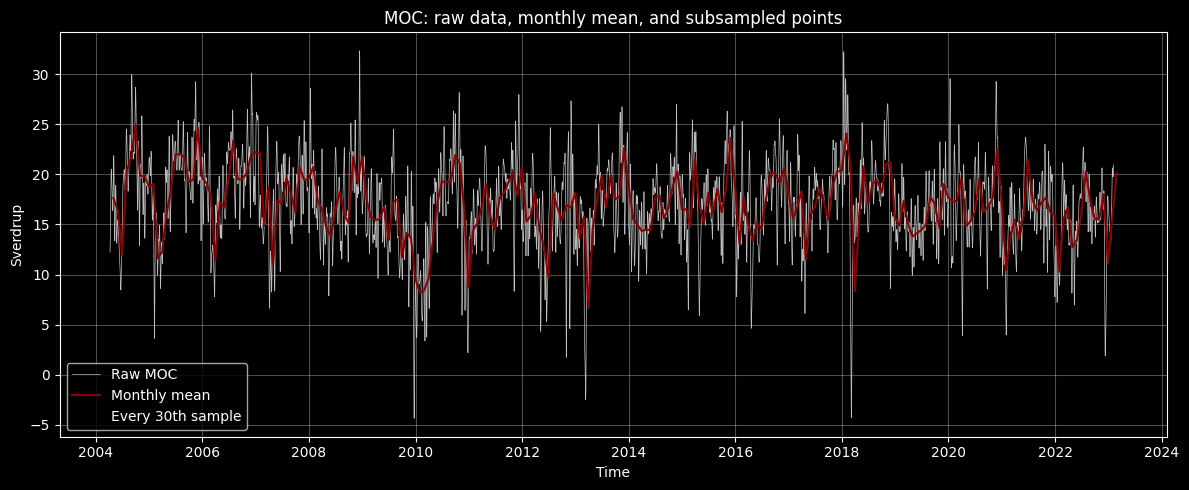

In [17]:
monthly = ds[component_vars.keys()].resample(TIME="ME").mean()
subsampled = ds[component_vars.keys()].isel(TIME=slice(None, None, 30))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ds["TIME"], ds["MOC"], color="0.75", linewidth=0.5, label="Raw MOC")
ax.plot(monthly["TIME"], monthly["MOC"], color="darkred", linewidth=1.5, label="Monthly mean")
ax.scatter(
    subsampled["TIME"],
    subsampled["MOC"],
    s=8,
    color="black",
    alpha=0.5,
    label="Every 30th sample",
)
ax.set_title("MOC: raw data, monthly mean, and subsampled points")
ax.set_ylabel(ds["MOC"].attrs.get("units", "Sv"))
ax.set_xlabel("Time")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "exercise1_moc_resampling.png", dpi=150)
plt.show()

## 9. Notes for Visual Evaluation

Use these prompts when writing the report:

- Which component has the largest mean transport?
- Which component varies the most, based on standard deviation and the time series plot?
- Are there visible gaps or sudden jumps?
- Does monthly averaging make the long-term variability easier to see?
- How do UMO, Florida Current, and Ekman relate to MOC variability?

In [18]:
summary = pd.DataFrame(
    {
        "largest_mean_component": [stats["mean"].idxmax()],
        "largest_std_component": [stats["standard_deviation"].idxmax()],
        "moc_mean_sv": [stats.loc["MOC", "mean"]],
        "moc_std_sv": [stats.loc["MOC", "standard_deviation"]],
        "time_start": [coverage.loc[0, "time_start"]],
        "time_end": [coverage.loc[0, "time_end"]],
        "sampling_interval": [coverage.loc[0, "most_common_sampling_interval"]],
    }
)
summary.round(3)

C:\Users\LYX\AppData\Local\Temp\ipykernel_59804\3307605165.py:12: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  summary.round(3)


,largest_mean_component,largest_std_component,moc_mean_sv,moc_std_sv,time_start,time_end,sampling_interval
0,TRANS_FC,MOC,17.042,4.354,2004-04-02,2023-02-11,0 days 12:00:00


## 10. Files Produced

The notebook saves three figures in the project `figures/` directory:

- `exercise1_transport_timeseries.png`
- `exercise1_transport_histograms.png`
- `exercise1_moc_resampling.png`

These can be used in `report.md` or for the figure discussion.